In [1]:
# !pyenv virtualenv-delete -f idp_explicabilidade_2026

In [2]:
# !pyenv virtualenv 3.13.4 idp_explicabilidade_2026

In [3]:
# !pyenv local idp_explicabilidade_2026

In [4]:
# !pip install --upgrade pip jupyterlab

In [5]:
# !jupyter-lab

In [6]:
!pip install --upgrade pip --quiet

In [7]:
!pip install --upgrade numpy --quiet

In [8]:
!pip install --upgrade pandas --quiet

In [9]:
!pip install --upgrade matplotlib --quiet

In [10]:
!pip install --upgrade scikit-learn --quiet

In [11]:
!pip install --upgrade graphviz pydotplus --quiet

In [12]:
!pip install --upgrade matplotlib --quiet

In [13]:
!pip install --upgrade seaborn --quiet

In [14]:
!pip install --upgrade lime --quiet

In [15]:
!pip install --upgrade shap --quiet

In [16]:
!pip install --upgrade joblib --quiet

👉 requer que o jupyter lab seja reiniciado

In [17]:
!pip install --upgrade ipywidgets jupyterlab_widgets --quiet

In [18]:
!sed -i .orig 's/IPython.core.display/IPython.display/g' ~/.pyenv/versions/3.13.4/envs/idp_explicabilidade_2026/lib/python3.13/site-packages/lime/explanation.py

In [19]:
from io import BytesIO

In [20]:
import requests

In [21]:
import numpy as np

In [22]:
import pandas as pd

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
from sklearn.tree import export_graphviz

In [25]:
import matplotlib.pyplot as plt

In [26]:
import seaborn as sns

In [27]:
from lime.lime_tabular import LimeTabularExplainer

In [28]:
import shap

shap.initjs();

In [29]:
from shap import Explainer

In [30]:
from shap.plots import bar

In [31]:
from shap.plots import waterfall

In [32]:
from shap.plots import force

In [33]:
from shap.plots import beeswarm

In [34]:
import joblib

In [35]:
from graphviz import Source

In [36]:
from IPython.display import HTML

In [37]:
from IPython.display import YouTubeVideo

In [38]:
def plotar_bairro(df, bairro):
    url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/california.png"
    california_img = requests.get(url, stream=True)
    california_img = BytesIO(california_img.content)
    
    with sns.axes_style("whitegrid"):
        fig = plt.figure(figsize=(10,4))
        sns.scatterplot(
            data=bairro,
            x="longitude",
            y="latitude",
            size="population",
            hue="median_house_value",
            palette=plt.get_cmap("jet"),
            legend=None,
            sizes=(bairro.population.min()/50, bairro.population.max()/50),
            ax=fig.gca()
        )
    
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap("jet"), norm=plt.Normalize(df["median_house_value"].min(), df["median_house_value"].max()))
        plt.colorbar(sm, label="median_house_value", ax=fig.gca())
    
        axis = -124.55, -113.95, 32.45, 42.05
        plt.axis(axis)
        plt.imshow(plt.imread(california_img), extent=axis);

# IA Explicável (XAI) 🕵🏼‍♀️

<p style="text-align: right">Prof. <a href="https://www.linkedin.com/in/heliomacedofilho/">Hélio Bomfim de Macêdo Filho</a><br />
<a href="https://www.idp.edu.br/mestrado/profissional-em-ciencia-de-dados">Mestrado em Administração Pública: Ciência de Dados e Inteligência Artificial no Setor Público</a></p>

## Sumário

<ul>
    <li>Motivação</li>
    <li>Conceitos</li>
    <ul>
        <li>Abordagens</li>
        <li>(Explicação) 📍 Local vs Global 🌎</li>
    </ul>
    <li>Abordagem Agnóstica</li>
    <ul>
        <li>Lime</li>
        <li>Shap</li>
    </ul>
</ul>

"Explainable AI (XAI) [...] is a field of research within artificial intelligence (AI) that explores methods that provide humans with the ability of intellectual oversight over AI algorithms."

<img src="https://static.seaflux.tech/media/blog/81d2e5c2-ac70-4d3c-9d3a-3cd7d80d1d90-blog-image.png" width=700>

## Motivação

- Conformidade Legal (e.g., LGPD);
- Depuração e Validação do Modelo;
- etc.

### Conformidade Legal

👉 Lei nº 13.709, de 14 de agosto de 2018 
- (Lei Geral de Proteção de Dados Pessoais)

[...]

Art. 20. O titular dos dados tem direito a solicitar a revisão de decisões tomadas **unicamente** com base em **tratamento automatizado** de dados pessoais que afetem seus interesses, incluídas [...].

§ 1º **O controlador** deverá fornecer, sempre que solicitadas, **informações claras e adequadas** a respeito dos **critérios** e dos **procedimentos utilizados** para a **decisão automatizada**, **observados os segredos** comercial e industrial.

[...]

### Depuração e Validação do Modelo

Vimos que o `RandomForestRegressor` pode indicar a importância relativa de cada atributo para fazer previsões precisas.

👉 Vamos carregar o modelo que geramos.

In [39]:
import joblib

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
def feature_names_out(function_transformer, feature_names_in):
    return ["ratio"]

modelo = joblib.load("modelo.pkl")

👉 Vamos carregar os dados sobre 
- a importância das características/variáveis no nosso modelo.

In [40]:
df_importancia = pd.DataFrame({"variaveis": 
                               modelo["columntransformer"].get_feature_names_out(),
                               "importancia": 
                               modelo["randomforestregressor"].feature_importances_}).sort_values('importancia', ascending=False)
df_importancia.head()

,variaveis,importancia
9,log__median_income,0.328188
1,cat__ocean_proximity_INLAND,0.153294
12,people_per_house__ratio,0.107797
10,bedrooms__ratio,0.078383
13,remainder__longitude,0.077074


👉 Entendemos a importância da característica/variável para o modelo...
- mas como ela contribui para predizer a característica-alvo?

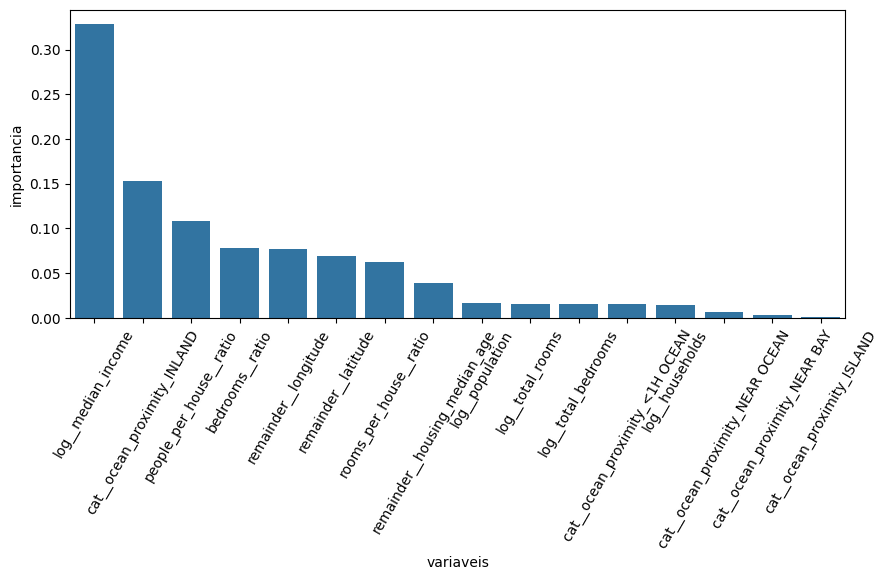

In [41]:
fig = plt.figure(figsize=(10, 4))
plt.xticks(rotation=60)
sns.barplot(data=df_importancia, x="variaveis", y="importancia");

👉 Vamos tentar interpretar o funcionamento do nosso modelo de Floresta Aleatória
- por seus mecanismos internos (regras de decisão).

In [42]:
f"Temos {len(modelo['randomforestregressor'].estimators_)} \
Árvores de Decisão"

'Temos 100 Árvores de Decisão'

👉 Veja o tamanho de uma única Árvore de Decisão (dentre 100!),
- interpretável na teoria, mas não na prática.

In [43]:
from sklearn.tree import export_graphviz
from graphviz import Source

export_graphviz(modelo['randomforestregressor'].estimators_[0],
                out_file="figs/modelo_estimador_0.dot",
                filled=True)

In [44]:
!dot -Tpng figs/modelo_estimador_0.dot -o figs/modelo_estimador_0.png

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.0589731 to fit


<img src="figs/modelo_estimador_0.png">

🚨 Impossível comunicar pra qualquer pessoa o que está de fato ocorrendo 🚨

Em geral, 
- temos uma correlação negativa entre
    - desempenho e
    - a explicação do que está de fato ocorrendo.

<center><img src="figs/explainability_vs_performance.png" width=400></center>

## Conceitos

<table>
    <tr>
        <th>Termo</th><th>Definição</th><th>Fonte</th>
    </tr>
    <tr>
        <td>Interpretabilidade</td><td>AI (3.1.13) level of understanding how the underlying (AI) technology works</td><td>Definição 3.1.42</td>
    </tr>
    <tr>
        <td>Explicabilidade</td><td>AI (3.1.13) level of understanding how the AI-based system (3.1.9) came up with a given result</td><td>Definição 3.1.31</td>
    </tr>
</table>

👉 Fonte: <a href="https://www.iso.org/obp/ui/en/#iso:std:iso-iec:tr:29119:-11:ed-1:v1:en">ISO/IEC TR 29119-11:2020</a>
- Software and systems engineering
- Software testing Part 11: Guidelines on the testing of AI-based systems

#### Abordagens

- Modelos explicáveis intrisicamente
    - Os parâmetros do modelo explicam diretamente
    - (como as características/variáveis contribuem para a previsão.)
    - <b>Exemplo</b>. Regressão Linear, Árvore de decisão, $k$-Nearest Neighbors.
- Agnóstico
    - O modelo de aprendizado de máquina é uma caixa-preta
    - A explicabilidade não assume nenhum conhecimento sobre o modelo utilizado.
    - Depende apenas das entradas e das previsões do modelo.
    - <b>Exemplo</b>. Floresta Aleatória, Redes Neurais Recorrentes.
- Específico do modelo
    - Conhecimento sobre o modelo de aprendizado de máquina é usado para gerar explicações.
    - <b>Exemplo</b>. *Gradient-weighted Class Activation Mapping* (Grad-CAM) para Redes Neurais Convolucionais

👉 Leia o artigo <a href="https://arxiv.org/pdf/2504.04276">A Comparative Study of Explainable AI Methods: Model-Agnostic vs. Model-Specific Approaches</a>.

### (Explicação) 📍 Local vs Global 🌎

- **global**: visão holística dos principais fatores que influenciam as previsões
    - (deste modelo.)
    - <b>exemplo</b>. vimos a importância das variáveis (*Feature Importance*)
- **local**: se concentram em gerar uma explicação de uma previsão específica
    - (feita pelo modelo.)
    - <b>exemplo</b>. veremos mais à frente com <b>LIME</b> e <b>SHAP</b>
        - (abordagens agnósticas).

<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*wd7Xd9bb7wrT0qAwi-FVew.png" width=700>

👉 Leia mais: <a href="https://medium.com/ing-blog/model-explainability-how-to-choose-the-right-tool-6c5eabd1a46a">Model Explainability — How to choose the right tool?</a>

### 👩‍🏫 Saiba Mais

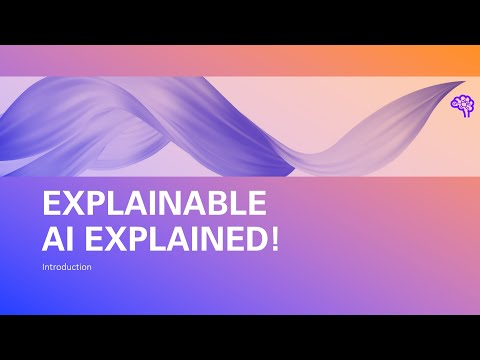

In [45]:
YouTubeVideo(id="OZJ1IgSgP9E", width="100%")

## Abordagem Agnóstica

👉 Antes de começar, vamos carregar nosso conjunto de dados.

In [46]:
df = pd.read_csv("../data/housing/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


👉 Vamos separar as características/variáveis da variável alvo,
- bem como separar os dados de treinamento e os dados de teste.

In [47]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns='median_house_value'), df['median_house_value']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y)

👉 Vamos treinar o modelo com dados de treinamento.

In [48]:
modelo.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default

👉 Vamos escolher arbitrariamente uma instância/bairro não vista no treinamento; e
- separar as características/variáveis da variável alvo.

In [49]:
bairro = df.sample(n=1)

In [50]:
x_bairro = bairro.drop(columns=['median_house_value'])
y_bairro = bairro['median_house_value']

In [51]:
x_bairro

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
6659,-115.56,32.96,21.0,2164.0,480.0,1164.0,421.0,3.8177,INLAND


👉 para que possamos explicar 
- o valor médio **predito** de uma residência abaixo
    - com **LIME** e **Shap**;

In [52]:
modelo.predict(x_bairro)

array([107873.74479989])

👉 Por último, vamos aplicar a sequência de transformações na 
- instância/bairro, para a explicação **local**; e
- subconjunto de testes, para a explicação **global**.

🚨 vamos usar (ambos) como entrada dos explicadores 
- **LIME** (explicação local); e
- **Shap** (explicação local e global).

In [53]:
x_bairro_transformado = pd.DataFrame(
    modelo["columntransformer"].transform(x_bairro), 
    columns=modelo["columntransformer"].get_feature_names_out()
)

In [54]:
X_teste_transformado = pd.DataFrame(
    modelo["columntransformer"].transform(X_teste), 
    columns=modelo["columntransformer"].get_feature_names_out()
)

### Lime

📚 Biblioteca Principal: <a href="https://lime.readthedocs.io/en/latest/">LIME</a>

In [55]:
from lime.lime_tabular import LimeTabularExplainer

"LIME approximates locally a model's outputs with a simpler, interpretable model."

👉 Leia o artigo <a href="https://dl.acm.org/doi/pdf/10.1145/2939672.2939778">Why Should I Trust You?” Explaining the Predictions of Any Classifier</a>.

👉 Vamos interpretar a instância/bairro escolhida.
- Qual a proximidade em relação ao oceano?
- Qual a renda média?
- etc.

In [56]:
x_bairro

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
6659,-115.56,32.96,21.0,2164.0,480.0,1164.0,421.0,3.8177,INLAND


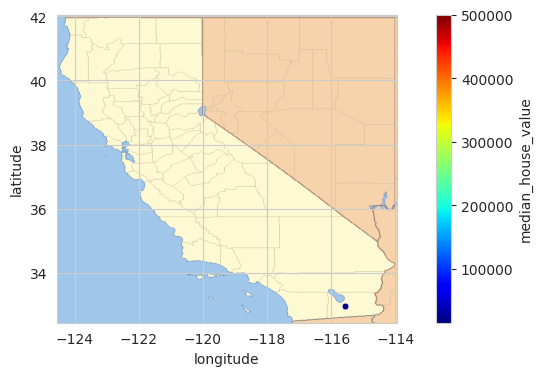

In [57]:
plotar_bairro(df, bairro)

Vamos criar o explicador.

In [58]:
explainer = LimeTabularExplainer(
    modelo["columntransformer"].transform(X_treino), 
    mode='regression',
    feature_names=modelo["columntransformer"].get_feature_names_out(), 
    class_names=['median_house_value'], 
    verbose=True
)

👉 Com o explicador, vamos explicar a predição da instância/bairro.
- Intercept: valor esperado da saída do modelo (`exp.intercept`)
- Right: valor predito (`modelo.predict(x_bairro)`)

$$Right = Intercept - \displaystyle\sum_{Feature \in Azul} Value_{Feature} + \displaystyle\sum_{Feature \in Laranja} Value_{Feature}$$

In [59]:
exp = explainer.explain_instance(
    x_bairro_transformado.values[0], 
    modelo['randomforestregressor'].predict, 
    num_features=5
)

Intercept 254541.2262156281
Prediction_local [164910.82921099]
Right: 107873.7447998908


👉 Vamos explicar a predição sobre a instância/bairro escolhida.
- Quanto contribui a proximidade em relação ao oceano?
- Quanto contribui a renda mediana?
- etc.

In [60]:
HTML(data=exp.as_html())
# exp.show_in_notebook() # (alternativamente)

#### 👩‍🏫 Saiba Mais

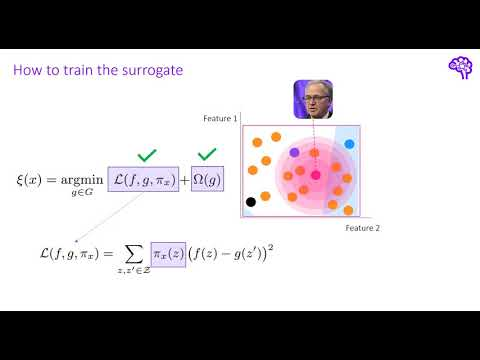

In [61]:
YouTubeVideo(id="d6j6bofhj2M", width="100%")

### Shap

📚 Biblioteca Principal: <a href="https://shap.readthedocs.io/en/latest/">SHAP</a>

In [62]:
import shap

shap.initjs();

<div style="text-align: right"><img src="https://cdn.prod.website-files.com/6108e07db6795265f203a636/61e7c023fc2e226de100b9e2_Shap.png" width=100></div>

**SHAP (SHapley Additive exPlanations)** enables visualization of the contribution of each input feature to the output.
- It works by calculating Shapley values,
- which measure the average marginal contribution of a feature across all possible combinations of features.

👉 Leia o artigo <a href="https://arxiv.org/pdf/1705.07874">A Unified Approach to Interpreting Model Predictions</a>.

"The Shapley value provides a principled way to explain the predictions of nonlinear models common in the field of machine learning."

<center><img src="https://shap.readthedocs.io/en/latest/_images/shap_header.png" width=500></center>

#### Local 📍

👉 Vamos relembrar a instância/bairro escolhida e interpretá-la.
- Qual a proximidade em relação ao oceano?
- Qual a renda média?
- etc.

In [63]:
x_bairro

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
6659,-115.56,32.96,21.0,2164.0,480.0,1164.0,421.0,3.8177,INLAND


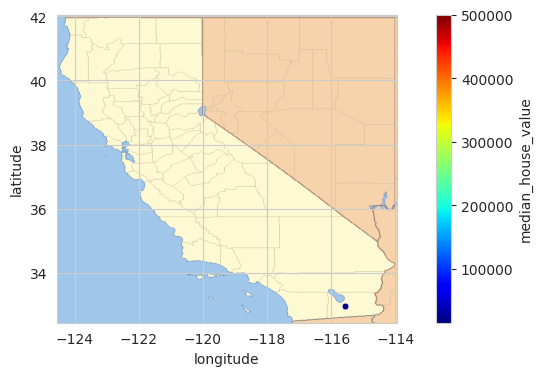

In [64]:
plotar_bairro(df, bairro)

Vamos criar o explicador **local**.

In [65]:
explicador = shap.Explainer(modelo["randomforestregressor"])

👉 Com o explicador, vamos explicar a predição da instância/bairro.

In [66]:
x_shap = explicador(x_bairro_transformado)

##### Gráfico de Barras 📊

Gráfico de importância local das variáveis, onde
- as barras representam os valores SHAP de cada característica/variável.

👉 Note que os valores das características/variáveis são exibidos em cinza 
- à esquerda dos nomes das características/variáveis.

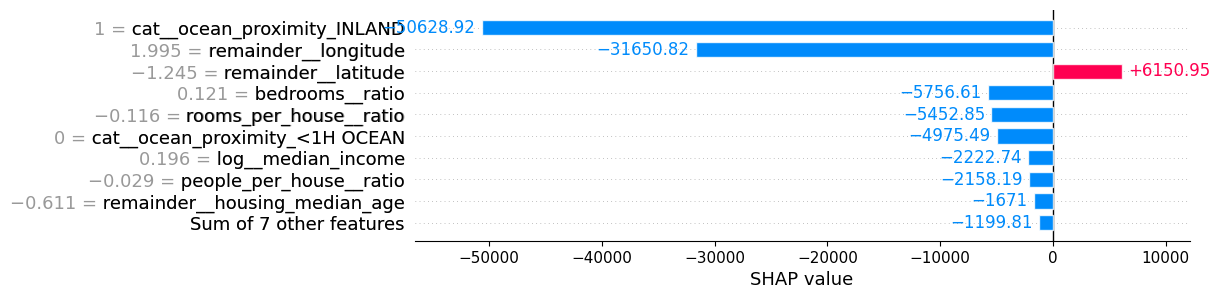

In [67]:
from shap.plots import bar

fig = plt.figure(figsize=(10, 3))

bar(x_shap[0], ax=fig.gca())

##### Gráfico Cascata 📉

- A base do gráfico em cascata começa com o valor esperado da saída do modelo
    - (`E[f(x)] = x_shap.base_values[0]`);
- cada linha mostra como a contribuição positiva (vermelha) ou negativa (azul)
    - de cada característica/variável (`x_shap.values`),
    - movendo o valor do resultado esperado do modelo,
    - calculado com base no conjunto de dados de fundo (`x_shap.values.sum()`)
- até o resultado final do modelo para essa predição específica
    - (`f(x) = modelo.predict(x_bairro)[0]`).

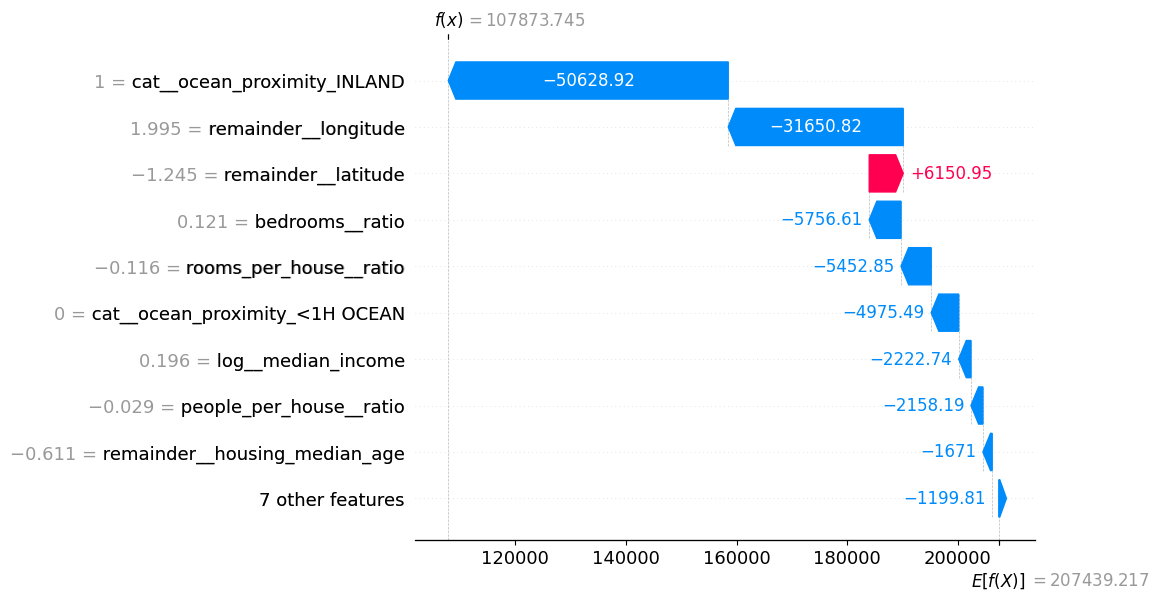

In [68]:
from shap.plots import waterfall

waterfall(x_shap[0])

##### Gráfico de Forças 💪

Gráfico de Cascata com agrupamento de múltiplas variáveis em uma única linha ou faixa.

In [69]:
from shap.plots import force

force(x_shap[0])

#### Global 🌎

👉 Vamos relembrar o subconjunto de teste.

In [70]:
X_teste.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
9625,-118.40,34.20,13.0,4859.0,1293.0,3351.0,1200.0,3.6875,<1H OCEAN
8696,-116.39,33.82,15.0,11115.0,2257.0,4122.0,1653.0,2.7219,INLAND
10468,-122.11,37.70,19.0,2693.0,789.0,1765.0,724.0,2.4206,NEAR BAY
7705,-117.06,33.01,24.0,2618.0,485.0,726.0,443.0,3.5192,<1H OCEAN
5366,-118.10,33.85,36.0,1473.0,253.0,713.0,257.0,5.9493,<1H OCEAN


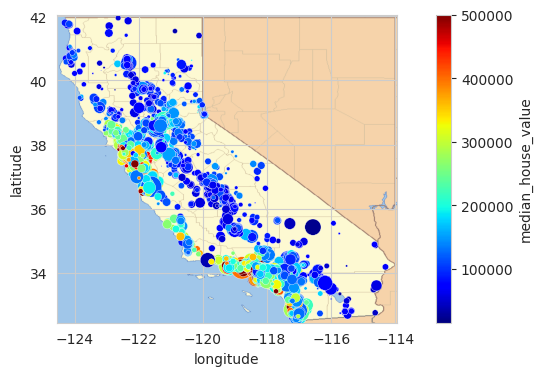

In [71]:
plotar_bairro(df, pd.concat([X_teste, y_teste], axis='columns'))

Vamos criar o explicador **global**.

In [72]:
from shap import Explainer

explicador = Explainer(modelo["randomforestregressor"])

👉 Com o explicador, vamos explicar a predição do subconjunto de teste.

In [73]:
%%time
X_shap = explicador(X_teste_transformado)

CPU times: user 6min 27s, sys: 1.17 s, total: 6min 29s
Wall time: 6min 29s


##### Gráfico de Barras 📊

Gráfico de importância global das variáveis, onde 
- a importância global de cada característica/variável
- calculada como o valor absoluto médio dessa característica/variável
    - em todas as amostras fornecidas (`np.abs(X_shap.values[:,varíavel]).mean()`).

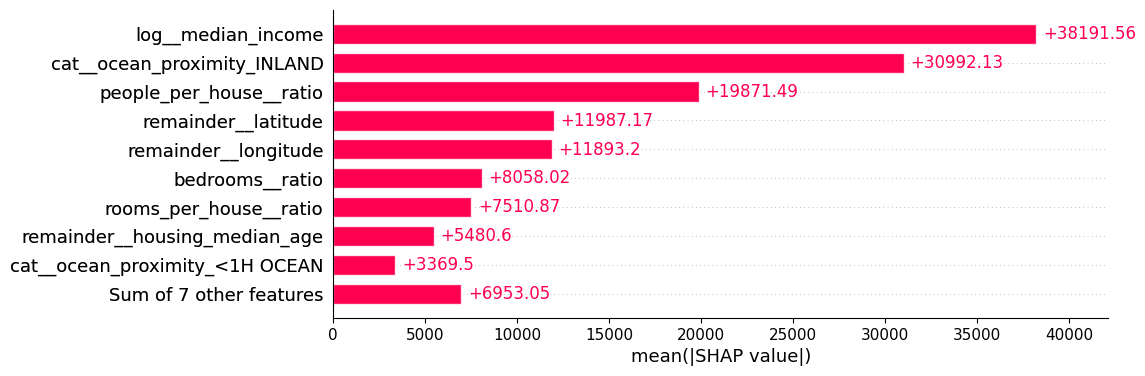

In [74]:
from shap.plots import bar

fig = plt.figure(figsize=(10, 4))

bar(X_shap, ax=fig.gca())

##### Gráfico de Coorte

Gráfico de barras múltiplas, com 
- um tipo de barra para cada grupo representado pelos objetos de explicação.

No exemplo abaixo, usamos isso para plotar um resumo global da importância das características/variáveis
- separadamente para classes sociais.

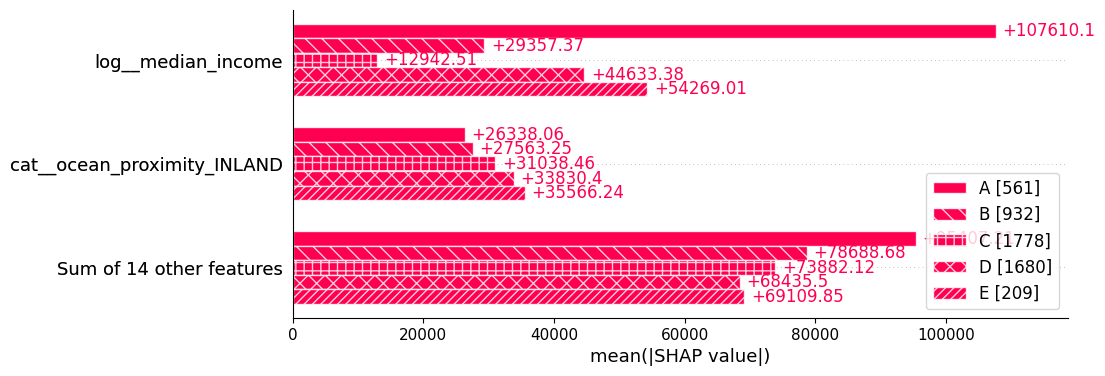

In [75]:
from shap.plots import bar

fig = plt.figure(figsize=(10, 4))

classe_social = pd.cut(X_teste['median_income'], 
                       bins=[0, 1.5, 3, 4.5, 6, np.inf], 
                       labels=["E", "D", "C", "B", "A"]).values.tolist()
bar(X_shap.cohorts(classe_social).abs.mean(0), 
    max_display=3, ax=fig.gca())

##### Gráfico de Enxame de Pontos 🐝

O gráfico **beeswarm** foi projetado para exibir um resumo denso em informações sobre 
- como as principais características/variáveis de um conjunto de dados
    - impactam a saída do modelo.

Cada instância/bairro na explicação fornecida é representada por um único ponto em cada linha de variável.
- **Eixo $x$**: A posição no eixo $x$ do ponto é determinada pelo valor SHAP dessa variável
    - (`X_shap.values[instância, variável]`);
- **Altura/Densidade**: os pontos se “acumulam” ao longo de cada linha
    - para indicar a densidade.
- **Cor**: a cor é usada para mostrar o valor original da variável
    - (`X_shap.data[instância, variável]`). 

No nosso caso, podemos ver que 
- a renda média (*log__median_income*) é, em média, a variável mais importante, e que 
- bairros de alta renda (em laranja) aumentam e muito o valor médio das residências.

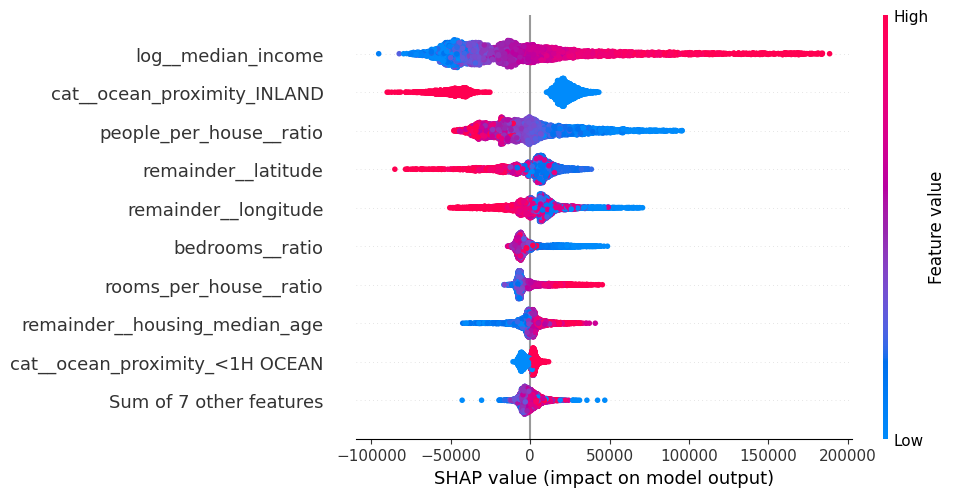

In [76]:
from shap.plots import beeswarm

beeswarm(X_shap)

### 👩‍🏫 Saiba Mais

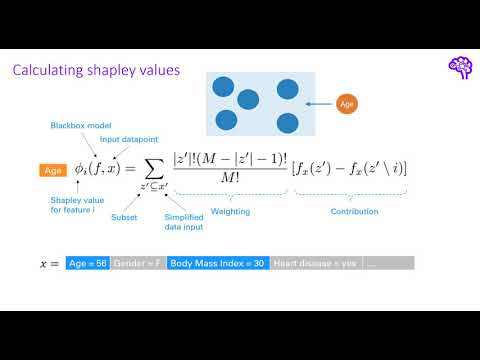

In [77]:
YouTubeVideo(id="9haIOplEIGM", width="100%")

<font size=7><center><code>Executem todo este caderno 🙂</code></center></font>